# Estudo de Machine Learning - Falencia de Empresas


## 1. Importacoes e carregamento dos dados

Nesta etapa, vamos importar as bibliotecas principais e carregar o arquivo `archive/data.csv`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.options.display.float_format = '{:.4f}'.format
sns.set_theme(style='whitegrid')

caminho_dados = 'archive/data.csv'
df = pd.read_csv(caminho_dados)
random_state = 42


## 2. Conhecimento inicial da base

Aqui vamos olhar a estrutura geral da base e confirmar a variavel alvo.


In [ ]:
display(df.head())
print(f'Shape da base: {df.shape}')


In [ ]:
df.info()


In [ ]:
estatisticas_descritivas = df.describe()

for inicio in range(0, len(estatisticas_descritivas.columns), 12):
    display(estatisticas_descritivas.iloc[:, inicio:inicio + 12])


In [ ]:
display(df.dtypes.to_frame(name='tipo_dado'))


In [ ]:
print('Lista de colunas:')
for coluna in df.columns:
    print('-', coluna)


In [ ]:
coluna_alvo = 'Bankrupt?'
print(f'Coluna alvo identificada: {coluna_alvo}')
display(df[coluna_alvo].value_counts().rename_axis('classe').reset_index(name='quantidade'))


## 3. Analise exploratoria inicial

Nesta etapa, vamos observar nulos, distribuicao do target, histogramas, boxplots e outliers.


In [ ]:
quantidade_nulos = df.isnull().sum()
percentual_nulos = (quantidade_nulos / len(df)) * 100

resumo_nulos = pd.DataFrame({
    'quantidade_nulos': quantidade_nulos,
    'percentual_nulos': percentual_nulos
})

resumo_nulos = resumo_nulos[resumo_nulos['quantidade_nulos'] > 0].sort_values(
    by='quantidade_nulos',
    ascending=False
)

display(resumo_nulos)


In [ ]:
distribuicao_target = df[coluna_alvo].value_counts().rename_axis('classe').reset_index(name='quantidade')
display(distribuicao_target)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=coluna_alvo)
plt.title('Distribuicao da variavel alvo')
plt.xlabel('Falencia')
plt.ylabel('Quantidade')
plt.show()


In [ ]:
colunas_preditoras = [coluna for coluna in df.columns if coluna != coluna_alvo]
colunas_numericas = df[colunas_preditoras].select_dtypes(include=['number']).columns.tolist()


In [ ]:
colunas_histograma = colunas_numericas[:6]
df[colunas_histograma].hist(figsize=(14, 8), bins=20)
plt.suptitle('Histogramas de variaveis numericas')
plt.tight_layout()
plt.show()


In [ ]:
def gerar_boxplot(coluna_inicial=0, coluna_final=20, y_inicial_original=None, y_final_original=None, y_inicial_padronizado=None, y_final_padronizado=None):
    colunas_boxplot = colunas_numericas[coluna_inicial:coluna_final]
    dados_boxplot = df[colunas_boxplot].copy()

    scaler = StandardScaler()
    dados_boxplot_padronizado = pd.DataFrame(
        scaler.fit_transform(dados_boxplot),
        columns=colunas_boxplot,
        index=dados_boxplot.index
    )

    figura, eixos = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    dados_boxplot.boxplot(ax=eixos[0])
    eixos[0].set_title('Boxplot de variaveis numericas - escala original')
    eixos[0].set_ylabel('Escala da variavel')
    if y_inicial_original is not None and y_final_original is not None:
        eixos[0].set_ylim(y_inicial_original, y_final_original)

    dados_boxplot_padronizado.boxplot(ax=eixos[1])
    eixos[1].set_title('Boxplot de variaveis numericas - escala padronizada')
    eixos[1].set_ylabel('Escala padronizada')
    if y_inicial_padronizado is not None and y_final_padronizado is not None:
        eixos[1].set_ylim(y_inicial_padronizado, y_final_padronizado)
    eixos[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [ ]:
def gerar_tabela_outliers(coluna_inicial=0, coluna_final=20):
    colunas_outliers = colunas_numericas[coluna_inicial:coluna_final]
    registros_outliers = []

    for coluna in colunas_outliers:
        q1 = df[coluna].quantile(0.25)
        q3 = df[coluna].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        mascara_outliers = (df[coluna] < limite_inferior) | (df[coluna] > limite_superior)
        quantidade_outliers = mascara_outliers.sum()
        percentual_outliers = (quantidade_outliers / len(df)) * 100

        registros_outliers.append({
            'coluna': coluna,
            'quantidade_outliers': quantidade_outliers,
            'percentual_outliers': percentual_outliers
        })

    return pd.DataFrame(registros_outliers).sort_values(by='percentual_outliers', ascending=False)


In [ ]:
coluna_inicial = 0
coluna_final = 20

y_inicial_original = -3
y_final_original = 3
y_inicial_padronizado = -3
y_final_padronizado = 3

gerar_boxplot(
    coluna_inicial=coluna_inicial,
    coluna_final=coluna_final,
    y_inicial_original=y_inicial_original,
    y_final_original=y_final_original,
    y_inicial_padronizado=y_inicial_padronizado,
    y_final_padronizado=y_final_padronizado
)

display(gerar_tabela_outliers(coluna_inicial=coluna_inicial, coluna_final=coluna_final))


## 4. Limpeza e preparacao inicial

Agora vamos fazer os ajustes simples e separar as variaveis preditoras da variavel alvo.


In [ ]:
colunas_originais = df.columns.tolist()
df.columns = df.columns.str.strip()
colunas_ajustadas = [
    {'antes': antes, 'depois': depois}
    for antes, depois in zip(colunas_originais, df.columns)
    if antes != depois
]

display(pd.DataFrame(colunas_ajustadas))


In [ ]:
X = df.drop(columns=coluna_alvo)
y = df[coluna_alvo]

print(f'X: {X.shape}')
print(f'y: {y.shape}')


In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=random_state
)

print(f'X_treino: {X_treino.shape}')
print(f'X_teste: {X_teste.shape}')
print(f'y_treino: {y_treino.shape}')
print(f'y_teste: {y_teste.shape}')


## 5. Pre-processamento

Nesta etapa, vamos montar o transformador para nulos, escalonamento e codificacao, quando necessario.


In [ ]:
colunas_numericas_modelagem = X_treino.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas_modelagem = X_treino.select_dtypes(exclude=['number']).columns.tolist()

transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('padronizador', StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(handle_unknown='ignore'))
])

pre_processador = ColumnTransformer(transformers=[
    ('numericas', transformador_numerico, colunas_numericas_modelagem),
    ('categoricas', transformador_categorico, colunas_categoricas_modelagem)
])


## 6. Rodada de modelos base sem balanceamento

Aqui vamos testar 5 modelos base sem balanceamento e comparar os resultados na mesma estrutura.


In [ ]:
def criacao_modelo(nome_modelo, estimador, X_treino, X_teste, y_treino, y_teste, pre_processador, cv=5, usar_smote=False):
    if usar_smote:
        pipeline_modelo = ImbPipeline(steps=[
            ('pre_processamento', pre_processador),
            ('smote', SMOTE(random_state=random_state)),
            ('modelo', estimador)
        ])
    else:
        pipeline_modelo = Pipeline(steps=[
            ('pre_processamento', pre_processador),
            ('modelo', estimador)
        ])

    pipeline_modelo.fit(X_treino, y_treino)

    previsoes_treino = pipeline_modelo.predict(X_treino)
    previsoes_teste = pipeline_modelo.predict(X_teste)

    acuracia_treino = accuracy_score(y_treino, previsoes_treino)
    acuracia_teste = accuracy_score(y_teste, previsoes_teste)
    diferenca_acuracia_treino_teste = abs(acuracia_treino - acuracia_teste)
    scores_validacao = cross_val_score(pipeline_modelo, X_treino, y_treino, cv=cv, scoring='accuracy')
    scores_cross_validation = [round(score, 4) for score in scores_validacao]
    diferenca_cross_validation = scores_validacao.max() - scores_validacao.min()
    relatorio_classificacao = classification_report(
        y_teste,
        previsoes_teste,
        output_dict=True,
        zero_division=0
    )

    return {
        'nome_modelo': nome_modelo,
        'pipeline_modelo': pipeline_modelo,
        'acuracia_treino': acuracia_treino,
        'acuracia_teste': acuracia_teste,
        'diferenca_acuracia_treino_teste': diferenca_acuracia_treino_teste,
        'cross_validation_media': scores_validacao.mean(),
        'cross_validation_desvio_padrao': scores_validacao.std(),
        'scores_cross_validation': scores_cross_validation,
        'diferenca_cross_validation': diferenca_cross_validation,
        'classification_report_dict': relatorio_classificacao
    }


In [ ]:
def gerar_tabela_classe_1(resultados_modelos):
    registros_classe_1 = []

    for resultado_modelo in resultados_modelos:
        metricas_classe_1 = resultado_modelo['classification_report_dict'].get('1', {})
        registros_classe_1.append({
            'nome_modelo': resultado_modelo['nome_modelo'],
            'precision_classe_1': metricas_classe_1.get('precision', 0),
            'recall_classe_1': metricas_classe_1.get('recall', 0),
            'f1_classe_1': metricas_classe_1.get('f1-score', 0),
            'support_classe_1': metricas_classe_1.get('support', 0)
        })

    return pd.DataFrame(registros_classe_1).sort_values(by='f1_classe_1', ascending=False).reset_index(drop=True)


def gerar_tabela_relatorio_classificacao(relatorio_classificacao):
    return pd.DataFrame(relatorio_classificacao).T


def gerar_tabela_classe_1_modelo(nome_modelo, relatorio_classificacao):
    metricas_classe_1 = relatorio_classificacao.get('1', {})
    return pd.DataFrame([
        {
            'nome_modelo': nome_modelo,
            'precision_classe_1': metricas_classe_1.get('precision', 0),
            'recall_classe_1': metricas_classe_1.get('recall', 0),
            'f1_classe_1': metricas_classe_1.get('f1-score', 0),
            'support_classe_1': metricas_classe_1.get('support', 0)
        }
    ])


def criar_estimador(nome_modelo, usar_balanceamento=False):
    if nome_modelo == 'Regressao Logistica':
        return LogisticRegression(
            max_iter=2000,
            random_state=random_state,
            class_weight='balanced' if usar_balanceamento else None
        )
    if nome_modelo == 'KNN':
        return KNeighborsClassifier()
    if nome_modelo == 'Arvore de Decisao':
        return DecisionTreeClassifier(
            random_state=random_state,
            class_weight='balanced' if usar_balanceamento else None
        )
    if nome_modelo == 'Random Forest':
        return RandomForestClassifier(
            random_state=random_state,
            class_weight='balanced' if usar_balanceamento else None
        )
    return SVC(
        random_state=random_state,
        class_weight='balanced' if usar_balanceamento else None
    )


def criar_modelos_base(usar_balanceamento=False):
    nomes_modelos = [
        'Regressao Logistica',
        'KNN',
        'Arvore de Decisao',
        'Random Forest',
        'SVM'
    ]
    return {
        nome_modelo: criar_estimador(nome_modelo, usar_balanceamento=usar_balanceamento)
        for nome_modelo in nomes_modelos
    }


def exibir_relatorios_modelos(resultados_modelos, titulo):
    print(titulo)

    for resultado_modelo in resultados_modelos:
        print(f"Modelo: {resultado_modelo['nome_modelo']}")
        print(
            f"Acuracia de treino: {resultado_modelo['acuracia_treino']:.4f} | "
            f"Acuracia de teste: {resultado_modelo['acuracia_teste']:.4f} | "
            f"Dif: {resultado_modelo['diferenca_acuracia_treino_teste']:.4f}"
        )
        print(
            f"CV: {resultado_modelo['scores_cross_validation']} | "
            f"Dif CV: {resultado_modelo['diferenca_cross_validation']:.4f}"
        )
        display(gerar_tabela_relatorio_classificacao(resultado_modelo['classification_report_dict']))
        print('-' * 90)


In [ ]:
modelos_base = criar_modelos_base(usar_balanceamento=False)


In [ ]:
resultados_modelos_base = []

for nome_modelo, estimador in modelos_base.items():
    resultado_modelo = criacao_modelo(
        nome_modelo=nome_modelo,
        estimador=estimador,
        X_treino=X_treino,
        X_teste=X_teste,
        y_treino=y_treino,
        y_teste=y_teste,
        pre_processador=pre_processador
    )
    resultados_modelos_base.append(resultado_modelo)


In [ ]:
tabela_modelos_base = pd.DataFrame(resultados_modelos_base).drop(columns=['pipeline_modelo', 'classification_report_dict'])
tabela_modelos_base = tabela_modelos_base.sort_values(by='acuracia_teste', ascending=False).reset_index(drop=True)


In [ ]:
tabela_classe_1_modelos_base = gerar_tabela_classe_1(resultados_modelos_base)


In [ ]:
exibir_relatorios_modelos(
    resultados_modelos_base,
    titulo='Relatorios detalhados - modelos base sem balanceamento'
)


In [ ]:
melhor_modelo_base = tabela_modelos_base.iloc[0]['nome_modelo']
print(f'Melhor modelo base sem PCA: {melhor_modelo_base}')


## 7. Rodada de modelos base com SMOTE

Nesta etapa, vamos repetir a rodada dos 5 modelos usando `SMOTE` apenas no treino para ampliar a representatividade da classe de empresas falidas.


In [ ]:
modelos_base_smote = criar_modelos_base(usar_balanceamento=False)

resultados_modelos_base_smote = []

for nome_modelo, estimador in modelos_base_smote.items():
    resultado_modelo = criacao_modelo(
        nome_modelo=nome_modelo,
        estimador=estimador,
        X_treino=X_treino,
        X_teste=X_teste,
        y_treino=y_treino,
        y_teste=y_teste,
        pre_processador=pre_processador,
        usar_smote=True
    )
    resultados_modelos_base_smote.append(resultado_modelo)


In [ ]:
tabela_modelos_base_smote = pd.DataFrame(resultados_modelos_base_smote).drop(columns=['pipeline_modelo', 'classification_report_dict'])
tabela_modelos_base_smote = tabela_modelos_base_smote.sort_values(by='acuracia_teste', ascending=False).reset_index(drop=True)


In [ ]:
tabela_classe_1_modelos_base_smote = gerar_tabela_classe_1(resultados_modelos_base_smote)


In [ ]:
exibir_relatorios_modelos(
    resultados_modelos_base_smote,
    titulo='Relatorios detalhados - modelos base com SMOTE'
)


In [ ]:
melhor_modelo_base_smote = tabela_modelos_base_smote.iloc[0]['nome_modelo']
print(f'Melhor modelo base com SMOTE: {melhor_modelo_base_smote}')


In [415]:
melhor_resultado_sem_balanceamento = next(
    resultado_modelo
    for resultado_modelo in resultados_modelos_base
    if resultado_modelo['nome_modelo'] == melhor_modelo_base
)

melhor_resultado_smote = next(
    resultado_modelo
    for resultado_modelo in resultados_modelos_base_smote
    if resultado_modelo['nome_modelo'] == melhor_modelo_base_smote
)

exibir_relatorios_modelos(
    [melhor_resultado_sem_balanceamento, melhor_resultado_smote],
    titulo='Relatorios detalhados - melhores modelos das estrategias sem balanceamento e com SMOTE'
)


Relatorios detalhados - melhores modelos das estrategias sem balanceamento e com SMOTE
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9702 | Dif: 0.0298
CV: [0.9686, 0.9707, 0.9707, 0.9727, 0.9706] | Dif CV: 0.0042


,precision,recall,f1-score,support
0,0.9734,0.9965,0.9848,1980.0000
1,0.6316,0.1818,0.2824,66.0000
accuracy,0.9702,0.9702,0.9702,0.9702
macro avg,0.8025,0.5891,0.6336,2046.0000
weighted avg,0.9623,0.9702,0.9621,2046.0000


------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9609 | Dif: 0.0391
CV: [0.9435, 0.9529, 0.9592, 0.9623, 0.9602] | Dif CV: 0.0188


,precision,recall,f1-score,support
0,0.9847,0.9747,0.9797,1980.0000
1,0.4186,0.5455,0.4737,66.0000
accuracy,0.9609,0.9609,0.9609,0.9609
macro avg,0.7016,0.7601,0.7267,2046.0000
weighted avg,0.9664,0.9609,0.9634,2046.0000


------------------------------------------------------------------------------------------


In [412]:
usar_smote = True

if usar_smote:
    descricao_trilha_smote = 'Com SMOTE'
    melhor_modelo_base_ativo = melhor_modelo_base_smote
else:
    descricao_trilha_smote = 'Sem SMOTE'
    melhor_modelo_base_ativo = melhor_modelo_base

print(f'Trilha escolhida para as proximas etapas: {descricao_trilha_smote}')
print(f'Melhor modelo base da estrategia escolhida: {melhor_modelo_base_ativo}')


Trilha escolhida para as proximas etapas: Com SMOTE
Melhor modelo base da estrategia escolhida: Random Forest


## 8. Otimizacao do melhor modelo da estrategia atual

Agora vamos usar Grid Search no melhor modelo da estrategia escolhida na etapa anterior, permitindo tambem testar `class_weight='balanced'` quando isso fizer sentido para o algoritmo.


In [413]:
if melhor_modelo_base_ativo == 'Regressao Logistica':
    melhor_estimador_sem_pca = LogisticRegression(max_iter=2000, random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__solver': ['lbfgs', 'liblinear'],
        'modelo__class_weight': [None, 'balanced']
    }
elif melhor_modelo_base_ativo == 'KNN':
    melhor_estimador_sem_pca = KNeighborsClassifier()
    grade_parametros_sem_pca = {
        'modelo__n_neighbors': [3, 5, 7, 9],
        'modelo__weights': ['uniform', 'distance']
    }
elif melhor_modelo_base_ativo == 'Arvore de Decisao':
    melhor_estimador_sem_pca = DecisionTreeClassifier(random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__max_depth': [3, 5, 10, None],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__class_weight': [None, 'balanced']
    }
elif melhor_modelo_base_ativo == 'Random Forest':
    melhor_estimador_sem_pca = RandomForestClassifier(random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [None, 5, 10],
        'modelo__min_samples_split': [2, 5],
        'modelo__class_weight': [None, 'balanced']
    }
else:
    melhor_estimador_sem_pca = SVC(random_state=random_state)
    grade_parametros_sem_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__kernel': ['linear', 'rbf'],
        'modelo__class_weight': [None, 'balanced']
    }


In [414]:
if usar_smote:
    pipeline_otimizacao_sem_pca = ImbPipeline(steps=[
        ('pre_processamento', pre_processador),
        ('smote', SMOTE(random_state=random_state)),
        ('modelo', melhor_estimador_sem_pca)
    ])
else:
    pipeline_otimizacao_sem_pca = Pipeline(steps=[
        ('pre_processamento', pre_processador),
        ('modelo', melhor_estimador_sem_pca)
    ])

grid_search_sem_pca = GridSearchCV(
    estimator=pipeline_otimizacao_sem_pca,
    param_grid=grade_parametros_sem_pca,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_sem_pca.fit(X_treino, y_treino)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre_processamento',
                                        ColumnTransformer(transformers=[('numericas',
                                                                         Pipeline(steps=[('imputador',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('padronizador',
                                                                                          StandardScaler())]),
                                                                         ['ROA(C) '
                                                                          'before '
                                                                          'interest '
                                                                          'and '
                                                                          'depreciation '
                                                                          'before '
                                                                          'interest',
                                                                          'ROA(A) '
                                                                          'before '
                                                                          'interest '
                                                                          'and '
                                                                          '% '
                                                                          'after '
                                                                          'tax',
                                                                          'ROA(B) '
                                                                          'before '
                                                                          'interest '
                                                                          'an...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('codificador',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         [])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('modelo',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': [None, 'balanced'],
                         'modelo__max_depth': [None, 5, 10],
                         'modelo__min_samples_split': [2, 5],
                         'modelo__n_estimators': [100, 200]},
             scoring='accuracy')

In [418]:
melhor_pipeline_sem_pca = grid_search_sem_pca.best_estimator_
previsoes_treino_sem_pca = melhor_pipeline_sem_pca.predict(X_treino)
previsoes_sem_pca = melhor_pipeline_sem_pca.predict(X_teste)

acuracia_treino_sem_pca = accuracy_score(y_treino, previsoes_treino_sem_pca)
acuracia_teste_sem_pca = accuracy_score(y_teste, previsoes_sem_pca)
diferenca_acuracia_sem_pca = abs(acuracia_treino_sem_pca - acuracia_teste_sem_pca)
scores_validacao_sem_pca = cross_val_score(
    melhor_pipeline_sem_pca,
    X_treino,
    y_treino,
    cv=5,
    scoring='accuracy'
)
scores_cross_validation_sem_pca = [round(score, 4) for score in scores_validacao_sem_pca]
diferenca_cross_validation_sem_pca = scores_validacao_sem_pca.max() - scores_validacao_sem_pca.min()

relatorio_sem_pca = classification_report(
    y_teste,
    previsoes_sem_pca,
    output_dict=True,
    zero_division=0
)

print('-' * 90)
print(f'Modelo: {melhor_modelo_base_ativo}')
print(
    f'Acuracia de treino: {acuracia_treino_sem_pca:.4f} | '
    f'Acuracia de teste: {acuracia_teste_sem_pca:.4f} | '
    f'Dif: {diferenca_acuracia_sem_pca:.4f}'
)
print(
    f'CV: {scores_cross_validation_sem_pca} | '
    f'Dif CV: {diferenca_cross_validation_sem_pca:.4f}'
)
print()
display(gerar_tabela_relatorio_classificacao(relatorio_sem_pca))
print('Melhores parametros sem PCA:')
print(grid_search_sem_pca.best_params_)


------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9609 | Dif: 0.0391
CV: [0.9435, 0.9529, 0.9592, 0.9623, 0.9602] | Dif CV: 0.0188



,precision,recall,f1-score,support
0,0.9847,0.9747,0.9797,1980.0000
1,0.4186,0.5455,0.4737,66.0000
accuracy,0.9609,0.9609,0.9609,0.9609
macro avg,0.7016,0.7601,0.7267,2046.0000
weighted avg,0.9664,0.9609,0.9634,2046.0000


Melhores parametros sem PCA:
{'modelo__class_weight': None, 'modelo__max_depth': None, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}


## 9. PCA e escolha da dimensionalidade

Nesta etapa, vamos estudar a variancia explicada acumulada para escolher a quantidade de componentes.


In [419]:
dados_treino_pre_processados = pre_processador.fit_transform(X_treino)

if hasattr(dados_treino_pre_processados, 'toarray'):
    dados_treino_pre_processados = dados_treino_pre_processados.toarray()


In [ ]:
pca_completo = PCA()
pca_completo.fit(dados_treino_pre_processados)

variancia_explicada_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)
tabela_pca = pd.DataFrame({
    'componente': np.arange(1, len(variancia_explicada_acumulada) + 1),
    'variancia_explicada_acumulada': variancia_explicada_acumulada
})

display(tabela_pca.head(15))


,componente,variancia_explicada_acumulada
0,1,0.1366
1,2,0.2110
2,3,0.2776
3,4,0.3275
4,5,0.3707
5,6,0.4071
6,7,0.4421
7,8,0.4725
8,9,0.4982
9,10,0.5210


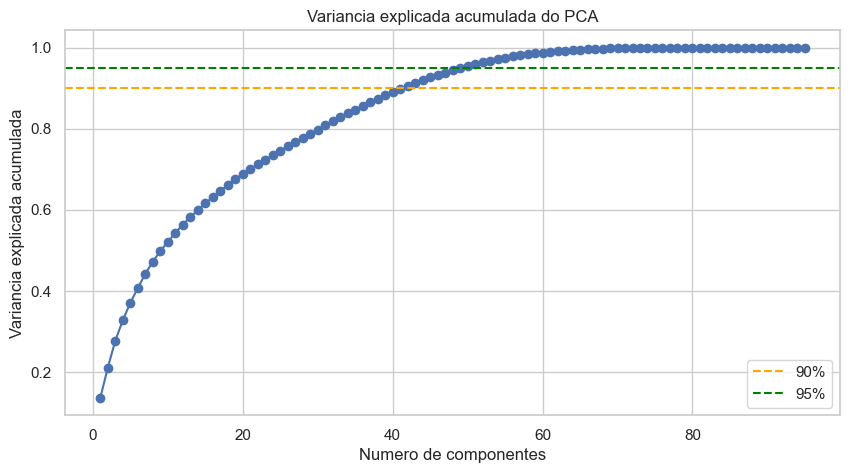

In [421]:
plt.figure(figsize=(10, 5))
plt.plot(tabela_pca['componente'], tabela_pca['variancia_explicada_acumulada'], marker='o')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90%')
plt.axhline(y=0.95, color='green', linestyle='--', label='95%')
plt.title('Variancia explicada acumulada do PCA')
plt.xlabel('Numero de componentes')
plt.ylabel('Variancia explicada acumulada')
plt.legend()
plt.show()


In [422]:
quantidade_componentes_pca = int((variancia_explicada_acumulada >= 0.95).argmax() + 1)
print(f'Quantidade inicial de componentes escolhida para o PCA: {quantidade_componentes_pca}')


Quantidade inicial de componentes escolhida para o PCA: 50


## 10. Rodada de modelos base com PCA

Agora vamos repetir a rodada de 5 modelos usando a base transformada por PCA e mantendo a estrategia escolhida.


In [423]:
pre_processador_com_pca = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('pca', PCA(n_components=quantidade_componentes_pca))
])


In [424]:
resultados_modelos_base_pca = []

for nome_modelo, estimador in modelos_base_ativos.items():
    resultado_modelo = criacao_modelo(
        nome_modelo=nome_modelo,
        estimador=estimador,
        X_treino=X_treino,
        X_teste=X_teste,
        y_treino=y_treino,
        y_teste=y_teste,
        pre_processador=pre_processador_com_pca
    )
    resultados_modelos_base_pca.append(resultado_modelo)


In [425]:
tabela_modelos_base_pca = pd.DataFrame(resultados_modelos_base_pca).drop(columns=['pipeline_modelo', 'classification_report_dict'])
tabela_modelos_base_pca = tabela_modelos_base_pca.sort_values(by='acuracia_teste', ascending=False).reset_index(drop=True)


In [426]:
tabela_classe_1_modelos_base_pca = gerar_tabela_classe_1(resultados_modelos_base_pca)


In [427]:
exibir_relatorios_modelos(
    resultados_modelos_base_pca,
    titulo='Relatorios detalhados - modelos base com PCA'
)


Relatorios detalhados - modelos base com PCA
Modelo: Regressao Logistica
Acuracia de treino: 0.9707 | Acuracia de teste: 0.9624 | Dif: 0.0083
CV: [0.9654, 0.9686, 0.9654, 0.9686, 0.9654] | Dif CV: 0.0032


,precision,recall,f1-score,support
0,0.9717,0.9899,0.9807,1980.0000
1,0.3103,0.1364,0.1895,66.0000
accuracy,0.9624,0.9624,0.9624,0.9624
macro avg,0.6410,0.5631,0.5851,2046.0000
weighted avg,0.9504,0.9624,0.9552,2046.0000


------------------------------------------------------------------------------------------
Modelo: KNN
Acuracia de treino: 0.9753 | Acuracia de teste: 0.9658 | Dif: 0.0095
CV: [0.9613, 0.9644, 0.9644, 0.9727, 0.9665] | Dif CV: 0.0115


,precision,recall,f1-score,support
0,0.9704,0.9949,0.9825,1980.0000
1,0.3750,0.0909,0.1463,66.0000
accuracy,0.9658,0.9658,0.9658,0.9658
macro avg,0.6727,0.5429,0.5644,2046.0000
weighted avg,0.9512,0.9658,0.9556,2046.0000


------------------------------------------------------------------------------------------
Modelo: Arvore de Decisao
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9453 | Dif: 0.0547
CV: [0.9518, 0.9361, 0.9487, 0.9476, 0.9507] | Dif CV: 0.0157


...

------------------------------------------------------------------------------------------
Modelo: Random Forest
Acuracia de treino: 1.0000 | Acuracia de teste: 0.9677 | Dif: 0.0323
CV: [0.9675, 0.9644, 0.9675, 0.9706, 0.9665] | Dif CV: 0.0063


,precision,recall,f1-score,support
0,0.9687,0.9990,0.9836,1980.0000
1,0.5000,0.0303,0.0571,66.0000
accuracy,0.9677,0.9677,0.9677,0.9677
macro avg,0.7343,0.5146,0.5204,2046.0000
weighted avg,0.9535,0.9677,0.9537,2046.0000


------------------------------------------------------------------------------------------
Modelo: SVM
Acuracia de treino: 0.9726 | Acuracia de teste: 0.9677 | Dif: 0.0048
CV: [0.9675, 0.9686, 0.9675, 0.9686, 0.9675] | Dif CV: 0.0011


,precision,recall,f1-score,support
0,0.9677,1.0000,0.9836,1980.0000
1,0.0000,0.0000,0.0000,66.0000
accuracy,0.9677,0.9677,0.9677,0.9677
macro avg,0.4839,0.5000,0.4918,2046.0000
weighted avg,0.9365,0.9677,0.9519,2046.0000


------------------------------------------------------------------------------------------


In [428]:
melhor_modelo_base_pca = tabela_modelos_base_pca.iloc[0]['nome_modelo']
print(f'Melhor modelo base com PCA: {melhor_modelo_base_pca}')


Melhor modelo base com PCA: Random Forest


## 11. Otimizacao do melhor modelo com PCA

Nesta etapa, vamos otimizar o melhor modelo encontrado na trilha com PCA, mantendo a estrategia escolhida.


In [429]:
valores_componentes_pca = sorted(set([
    max(2, quantidade_componentes_pca - 2),
    quantidade_componentes_pca,
    min(len(colunas_numericas_modelagem), quantidade_componentes_pca + 2)
]))

if melhor_modelo_base_pca == 'Regressao Logistica':
    melhor_estimador_com_pca = criar_estimador('Regressao Logistica', usar_balanceamento=usar_balanceamento)
    grade_parametros_com_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__solver': ['lbfgs', 'liblinear'],
        'pca__n_components': valores_componentes_pca
    }
elif melhor_modelo_base_pca == 'KNN':
    melhor_estimador_com_pca = criar_estimador('KNN', usar_balanceamento=usar_balanceamento)
    grade_parametros_com_pca = {
        'modelo__n_neighbors': [3, 5, 7, 9],
        'modelo__weights': ['uniform', 'distance'],
        'pca__n_components': valores_componentes_pca
    }
elif melhor_modelo_base_pca == 'Arvore de Decisao':
    melhor_estimador_com_pca = criar_estimador('Arvore de Decisao', usar_balanceamento=usar_balanceamento)
    grade_parametros_com_pca = {
        'modelo__max_depth': [3, 5, 10, None],
        'modelo__min_samples_split': [2, 5, 10],
        'pca__n_components': valores_componentes_pca
    }
elif melhor_modelo_base_pca == 'Random Forest':
    melhor_estimador_com_pca = criar_estimador('Random Forest', usar_balanceamento=usar_balanceamento)
    grade_parametros_com_pca = {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [None, 5, 10],
        'modelo__min_samples_split': [2, 5],
        'pca__n_components': valores_componentes_pca
    }
else:
    melhor_estimador_com_pca = criar_estimador('SVM', usar_balanceamento=usar_balanceamento)
    grade_parametros_com_pca = {
        'modelo__C': [0.1, 1, 10],
        'modelo__kernel': ['linear', 'rbf'],
        'pca__n_components': valores_componentes_pca
    }


In [430]:
pipeline_otimizacao_com_pca = Pipeline(steps=[
    ('pre_processamento', pre_processador),
    ('pca', PCA(n_components=quantidade_componentes_pca)),
    ('modelo', melhor_estimador_com_pca)
])

grid_search_com_pca = GridSearchCV(
    estimator=pipeline_otimizacao_com_pca,
    param_grid=grade_parametros_com_pca,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_com_pca.fit(X_treino, y_treino)


KeyboardInterrupt: 

In [ ]:
melhor_pipeline_com_pca = grid_search_com_pca.best_estimator_
previsoes_com_pca = melhor_pipeline_com_pca.predict(X_teste)
relatorio_com_pca = classification_report(
    y_teste,
    previsoes_com_pca,
    output_dict=True,
    zero_division=0
)

tabela_resumo_com_pca = pd.DataFrame([
    {
        'trilha_smote_escolhida': descricao_trilha_smote,
        'melhor_modelo_com_pca': melhor_modelo_base_pca,
        'melhor_score_validacao_com_pca': grid_search_com_pca.best_score_,
        'acuracia_teste_com_pca': accuracy_score(y_teste, previsoes_com_pca)
    }
])

display(tabela_resumo_com_pca)
display(gerar_tabela_classe_1_modelo(melhor_modelo_base_pca, relatorio_com_pca))
display(gerar_tabela_relatorio_classificacao(relatorio_com_pca))
print('Melhores parametros com PCA:')
print(grid_search_com_pca.best_params_)


## 12. Comparacao final e conclusao

Por fim, vamos reunir os resultados das duas trilhas para apoiar a conclusao do estudo.


In [ ]:
comparacao_final = pd.DataFrame([
    {
        'abordagem': 'Sem PCA',
        'trilha_smote': descricao_trilha_smote,
        'modelo': melhor_modelo_base_ativo,
        'melhor_score_validacao': grid_search_sem_pca.best_score_,
        'acuracia_teste': accuracy_score(y_teste, previsoes_sem_pca)
    },
    {
        'abordagem': 'Com PCA',
        'trilha_smote': descricao_trilha_smote,
        'modelo': melhor_modelo_base_pca,
        'melhor_score_validacao': grid_search_com_pca.best_score_,
        'acuracia_teste': accuracy_score(y_teste, previsoes_com_pca)
    }
])

comparacao_final = comparacao_final.sort_values(by='acuracia_teste', ascending=False).reset_index(drop=True)
display(comparacao_final)


In [ ]:
melhor_abordagem_final = comparacao_final.iloc[0]
print('Melhor abordagem final do estudo:')
print(melhor_abordagem_final)
